# Optimizing Sky Traffic: Improved Modelling Pipeline

This notebook is a **self-contained upgrade** of the original project. Keep `Airline_Delay_Cause.csv` in the same folder and run top to bottom.

It adds the pieces the first version was missing:

| # | Addition | Why it matters |
|---|---|---|
| 1 | **Time-based train/test split** | Train on 2020-2024, test on 2025-2026, so the model is judged on the future |
| 2 | **Baseline models** | Shows whether the ML model beats trivial predictors |
| 3 | **Lag and rolling features** | Past delay at the same carrier-airport is a strong signal |
| 4 | **Hyperparameter tuning with time-series CV** | Replaces hand-picked settings; also tests a raw-minute target vs. the log target |
| 5 | **Feature importance (permutation + SHAP)** | Explains what drives predictions |
| 6 | **Error analysis** | Shows where the model is accurate and where it fails |

In [1]:
!pip install -q xgboost catboost shap

In [2]:
import os
print(os.getcwd())

C:\Users\DELL\Downloads


In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

DATA_PATH = "Airline_Delay_Cause.csv"
RANDOM_STATE = 42
TRAIN_END_YEAR = 2024        # train on years <= this, test on every later year
N_ITER_XGB, N_ITER_CAT = 12, 6   # number of random-search candidates (raise for a wider search)

## 1. Load and clean

Rows with a missing target (`arr_delay`) or flight count are **dropped**, not imputed. Filling in the value we are trying to predict would inject made-up labels into training.

In [4]:
raw = pd.read_csv(DATA_PATH)
raw = raw.loc[:, ~raw.columns.str.startswith("Unnamed")]

before = len(raw)
raw = raw.dropna(subset=["arr_delay", "arr_flights"]).copy()
print(f"Dropped {before - len(raw)} rows with a missing target or flight count; {len(raw):,} rows remain")

raw["date"] = pd.to_datetime(raw[["year", "month"]].assign(day=1))
raw["t"] = raw["year"] * 12 + raw["month"]        # integer month index, used to build lags

raw = raw.drop_duplicates(["carrier", "airport", "t"])   # lag merge needs one row per carrier-airport-month
print("Date range:", raw["date"].min().date(), "to", raw["date"].max().date())

Dropped 184 rows with a missing target or flight count; 136,692 rows remain
Date range: 2020-07-01 to 2026-07-01


## 2. Lag and rolling features

For each carrier-airport pair we add the delay from 1, 2, 3 and 12 months earlier, a 3-month rolling average, and last month's flight volume.
Every one of these uses **only past months**, so there is no leakage. The first months of the dataset have no history, so those lags are `NaN`, which XGBoost and CatBoost handle natively.

In [5]:
def add_lag(df, col, k, name):
    lag = df[["carrier", "airport", "t", col]].copy()
    lag["t"] = lag["t"] + k                  # value from k months ago lines up with month t
    return df.merge(lag.rename(columns={col: name}), on=["carrier", "airport", "t"], how="left")

df = raw.copy()
for k in (1, 2, 3, 12):
    df = add_lag(df, "arr_delay", k, f"lag{k}_delay")
df = add_lag(df, "arr_flights", 1, "lag1_flights")

df["roll3_delay"] = df[["lag1_delay", "lag2_delay", "lag3_delay"]].mean(axis=1)
df["lag1_delay_per_flight"] = (df["lag1_delay"] / df["lag1_flights"]).replace([np.inf, -np.inf], np.nan)

# calendar features and encodings (same ideas as the original notebook)
df["quarter"] = df["date"].dt.quarter
df["is_summer_peak"] = df["month"].isin([6, 7, 8]).astype(int)
df["is_holiday_peak"] = df["month"].isin([11, 12, 1]).astype(int)
df["carrier_id"] = LabelEncoder().fit_transform(df["carrier"].astype(str))
df["airport_id"] = LabelEncoder().fit_transform(df["airport"].astype(str))
df["y_log"] = np.log1p(df["arr_delay"].clip(lower=0))     # log target, as in the original

ORIGINAL_FEATS = ["year", "month", "carrier_id", "airport_id", "arr_flights",
                  "quarter", "is_summer_peak", "is_holiday_peak"]
LAG_FEATS = ["lag1_delay", "lag2_delay", "lag3_delay", "lag12_delay",
             "roll3_delay", "lag1_flights", "lag1_delay_per_flight"]
# 'year' is removed for the improved model: with a time-based split the test years are never
# seen in training, so a tree cannot use it meaningfully.
IMPROVED_FEATS = [f for f in ORIGINAL_FEATS if f != "year"] + LAG_FEATS

print("Share of rows with each lag available:")
print(df[LAG_FEATS].notna().mean().round(3).to_string())

Share of rows with each lag available:
lag1_delay               0.952
lag2_delay               0.920
lag3_delay               0.896
lag12_delay              0.758
roll3_delay              0.966
lag1_flights             0.952
lag1_delay_per_flight    0.952


## 3. Time-based split, and why it matters

The original notebook used a random 80/20 split, which lets the model train on months that come *after* some of its test months.
Here we train on **2020-2024** and test on **2025 onward**. 2026 is a partial year (data ends in July), so it is evaluated together with 2025.

The cell below also reruns the original setup (same 8 features, same model) both ways, so you can see how much the random split flattered the result.

In [6]:
def metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "WAPE %": 100 * np.abs(y_true - y_pred).sum() / y_true.sum(),   # total error as a share of total delay
    }

train = df[df["year"] <= TRAIN_END_YEAR].sort_values("date").reset_index(drop=True)
test = df[df["year"] > TRAIN_END_YEAR].reset_index(drop=True)
print(f"Train: {len(train):,} rows ({train.year.min()}-{train.year.max()})")
print(f"Test : {len(test):,} rows ({test.year.min()}-{test.year.max()})")

def quick_xgb():
    return XGBRegressor(n_estimators=250, learning_rate=0.04, max_depth=6,
                        random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist")

# original setup, random split
rs_tr, rs_te = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)
m = quick_xgb().fit(rs_tr[ORIGINAL_FEATS], rs_tr["y_log"])
random_res = metrics(rs_te["arr_delay"], np.expm1(m.predict(rs_te[ORIGINAL_FEATS])))

# same model and features, time-based split
m = quick_xgb().fit(train[ORIGINAL_FEATS], train["y_log"])
time_res = metrics(test["arr_delay"], np.expm1(m.predict(test[ORIGINAL_FEATS])))

display(pd.DataFrame({"Random split (original)": random_res, "Time-based split": time_res}).T.round(3))

Train: 101,060 rows (2020-2024)
Test : 35,632 rows (2025-2026)


,MAE,RMSE,R2,WAPE %
Random split (original),1221.719,5473.769,0.877,27.208
Time-based split,1792.905,6846.582,0.852,31.908


## 4. Baseline models

A model is only impressive if it beats simple alternatives. Three baselines:
- **Linear on flights only**: total delay minutes mostly scale with flight volume, so this tests how much of the original R² was just volume.
- **Last month's delay**: "next month looks like this month".
- **Same month last year**: a seasonal version of the same idea.

Where a lag is missing, the baselines fall back to the linear prediction.

In [7]:
results = {}

lin = LinearRegression().fit(train[["arr_flights"]], train["arr_delay"])
lin_pred = pd.Series(lin.predict(test[["arr_flights"]]).clip(min=0), index=test.index)

results["Baseline: linear on flights only"] = metrics(test["arr_delay"], lin_pred)
results["Baseline: last month's delay"] = metrics(test["arr_delay"], test["lag1_delay"].fillna(lin_pred))
results["Baseline: same month last year"] = metrics(test["arr_delay"], test["lag12_delay"].fillna(lin_pred))
results["XGBoost, original 8 features"] = time_res

print("Test rows where the baseline had its lag available:",
      f"lag1 = {test['lag1_delay'].notna().mean():.1%}, lag12 = {test['lag12_delay'].notna().mean():.1%}")
display(pd.DataFrame(results).T.round(3))

Test rows where the baseline had its lag available: lag1 = 97.3%, lag12 = 92.0%


,MAE,RMSE,R2,WAPE %
Baseline: linear on flights only,2149.089,8164.746,0.789,38.247
Baseline: last month's delay,1976.272,6386.891,0.871,35.172
Baseline: same month last year,2155.869,7336.762,0.830,38.368
"XGBoost, original 8 features",1792.905,6846.582,0.852,31.908


## 5. Hyperparameter tuning with time-series cross-validation

`TimeSeriesSplit` always trains on earlier rows and validates on later ones, so the tuning respects time order. The final test years are never touched during tuning.

Note: `StackingRegressor` cannot be combined with time-series CV (its internal cross-validation needs a random partition), so the final model here is a simple **average of the tuned XGBoost and CatBoost predictions**. The original stacking notebook can stay in the repo as your first version.

In [8]:
X_tr, y_tr = train[IMPROVED_FEATS], train["y_log"]
X_te, y_te_log = test[IMPROVED_FEATS], test["y_log"]
tscv = TimeSeriesSplit(n_splits=4)

xgb_space = {
    "n_estimators": [200, 400, 600],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "min_child_weight": [1, 5, 10],
}
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist"),
    xgb_space, n_iter=N_ITER_XGB, cv=tscv, scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=1, verbose=1)
xgb_search.fit(X_tr, y_tr)
print("Best XGBoost params:", xgb_search.best_params_)
print("CV RMSE (log scale):", round(-xgb_search.best_score_, 4))

Fitting 4 folds for each of 12 candidates, totalling 48 fits
Best XGBoost params: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
CV RMSE (log scale): 0.9791


Best XGBoost params: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
CV RMSE (log scale): 0.9778


In [9]:
cat_space = {
    "depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "iterations": [300, 500],
    "l2_leaf_reg": [1, 3, 5, 9],
}
cat_search = RandomizedSearchCV(
    CatBoostRegressor(random_state=RANDOM_STATE, verbose=0, thread_count=-1, allow_writing_files=False),
    cat_space, n_iter=N_ITER_CAT, cv=tscv, scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=1, verbose=1)
cat_search.fit(X_tr, y_tr)
print("Best CatBoost params:", cat_search.best_params_)
print("CV RMSE (log scale):", round(-cat_search.best_score_, 4))

Fitting 4 folds for each of 6 candidates, totalling 24 fits
Best CatBoost params: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 300, 'depth': 6}
CV RMSE (log scale): 0.9764


Best CatBoost params: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 300, 'depth': 6}
CV RMSE (log scale): 0.9764


### 5b. Is the log transform hurting?

Training on `log(delay)` optimises *relative* error, and converting predictions back with `expm1` tends to land **below** the true average, especially for the biggest airports that carry most of the delay minutes. The check below compares total predicted minutes with total actual minutes (1.0 would be unbiased).

In [10]:
bias_log = np.expm1(xgb_search.best_estimator_.predict(X_te)).clip(min=0).sum() / test["arr_delay"].sum()
print(f"Log-target XGBoost: total predicted / total actual delay = {bias_log:.3f}")

Log-target XGBoost: total predicted / total actual delay = 0.873


If that ratio is clearly below 1, the model is systematically under-predicting. Because delay minutes are summed across the whole network, we also tune both models **directly on raw delay minutes** and compare.

In [11]:
y_tr_raw = train["arr_delay"]

xgb_raw_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist"),
    xgb_space, n_iter=N_ITER_XGB, cv=tscv, scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=1, verbose=1)
xgb_raw_search.fit(X_tr, y_tr_raw)
print("Best XGBoost (raw minutes) params:", xgb_raw_search.best_params_)

cat_raw_search = RandomizedSearchCV(
    CatBoostRegressor(random_state=RANDOM_STATE, verbose=0, thread_count=-1, allow_writing_files=False),
    cat_space, n_iter=N_ITER_CAT, cv=tscv, scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=1, verbose=1)
cat_raw_search.fit(X_tr, y_tr_raw)
print("Best CatBoost (raw minutes) params:", cat_raw_search.best_params_)

Fitting 4 folds for each of 12 candidates, totalling 48 fits
Best XGBoost (raw minutes) params: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 10, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Fitting 4 folds for each of 6 candidates, totalling 24 fits
Best CatBoost (raw minutes) params: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 300, 'depth': 6}


Best XGBoost (raw minutes) params: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 10, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Fitting 4 folds for each of 6 candidates, totalling 24 fits


Best CatBoost (raw minutes) params: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 300, 'depth': 6}


## 6. Final comparison on the held-out future (2025 onward)

,MAE,RMSE,R2,WAPE %
"FINAL: Blend, raw minutes",1494.309,5272.720,0.912,26.594
"CatBoost + lags, raw minutes (tuned)",1540.251,5274.483,0.912,27.412
"XGBoost + lags, raw minutes (tuned)",1490.546,5416.149,0.907,26.527
Baseline: last month's delay,1976.272,6386.891,0.871,35.172
"XGBoost, original 8 features",1792.905,6846.582,0.852,31.908
"CatBoost + lags, log target (tuned)",1609.131,7010.539,0.845,28.638
"Blend, log target",1603.289,7188.563,0.837,28.534
Baseline: same month last year,2155.869,7336.762,0.830,38.368
"XGBoost + lags, log target (tuned)",1618.941,7436.247,0.825,28.812
Baseline: linear on flights only,2149.089,8164.746,0.789,38.247


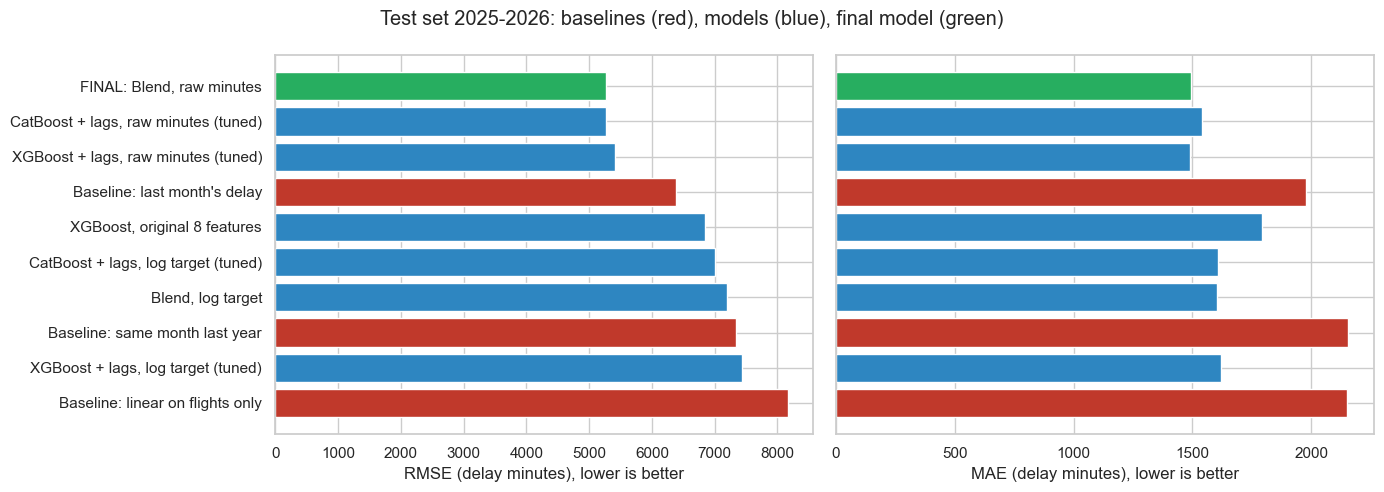

In [12]:
# models trained on log(delay): convert predictions back to minutes
lx = np.expm1(xgb_search.best_estimator_.predict(X_te)).clip(min=0)
lc = np.expm1(cat_search.best_estimator_.predict(X_te)).clip(min=0)
results["XGBoost + lags, log target (tuned)"] = metrics(test["arr_delay"], lx)
results["CatBoost + lags, log target (tuned)"] = metrics(test["arr_delay"], lc)
results["Blend, log target"] = metrics(test["arr_delay"], (lx + lc) / 2)

# models trained directly on raw delay minutes
best_xgb = xgb_raw_search.best_estimator_
best_cat = cat_raw_search.best_estimator_
rx = best_xgb.predict(X_te).clip(min=0)
rc = best_cat.predict(X_te).clip(min=0)
final_pred = (rx + rc) / 2
results["XGBoost + lags, raw minutes (tuned)"] = metrics(test["arr_delay"], rx)
results["CatBoost + lags, raw minutes (tuned)"] = metrics(test["arr_delay"], rc)
results["FINAL: Blend, raw minutes"] = metrics(test["arr_delay"], final_pred)

summary = pd.DataFrame(results).T.round(3).sort_values("RMSE")
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = ["#c0392b" if n.startswith("Baseline") else ("#27ae60" if n.startswith("FINAL") else "#2e86c1")
          for n in summary.index]
for ax, metric, label in [(axes[0], "RMSE", "RMSE (delay minutes)"), (axes[1], "MAE", "MAE (delay minutes)")]:
    ax.barh(summary.index[::-1], summary[metric][::-1], color=colors[::-1])
    ax.set_xlabel(label + ", lower is better")
fig.suptitle("Test set 2025-2026: baselines (red), models (blue), final model (green)")
plt.tight_layout(); plt.show()

## 7. Feature importance

**Permutation importance** shuffles one feature at a time on the test set and measures how much the error rises, so it works on the final model and the real test data. **SHAP** then shows the direction of each feature's effect.

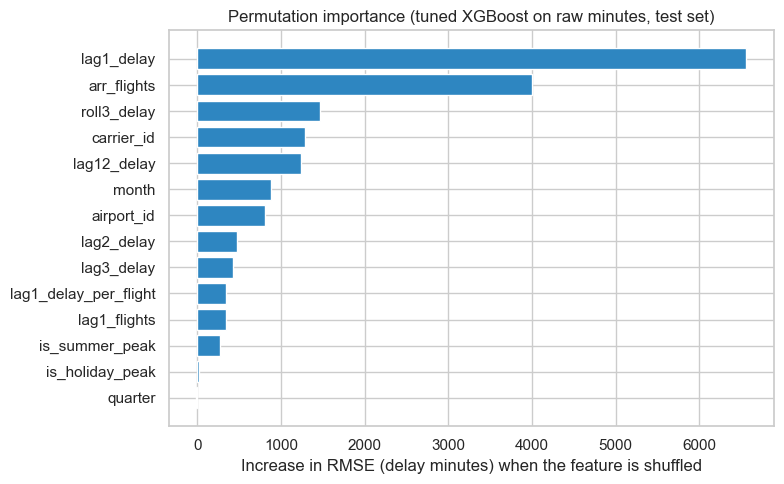

In [13]:
perm = permutation_importance(best_xgb, X_te, test["arr_delay"], n_repeats=5,
                              random_state=RANDOM_STATE, scoring="neg_root_mean_squared_error")
imp = pd.Series(perm.importances_mean, index=IMPROVED_FEATS).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp.index, imp.values, color="#2e86c1")
ax.set_xlabel("Increase in RMSE (delay minutes) when the feature is shuffled")
ax.set_title("Permutation importance (tuned XGBoost on raw minutes, test set)")
plt.tight_layout(); plt.show()

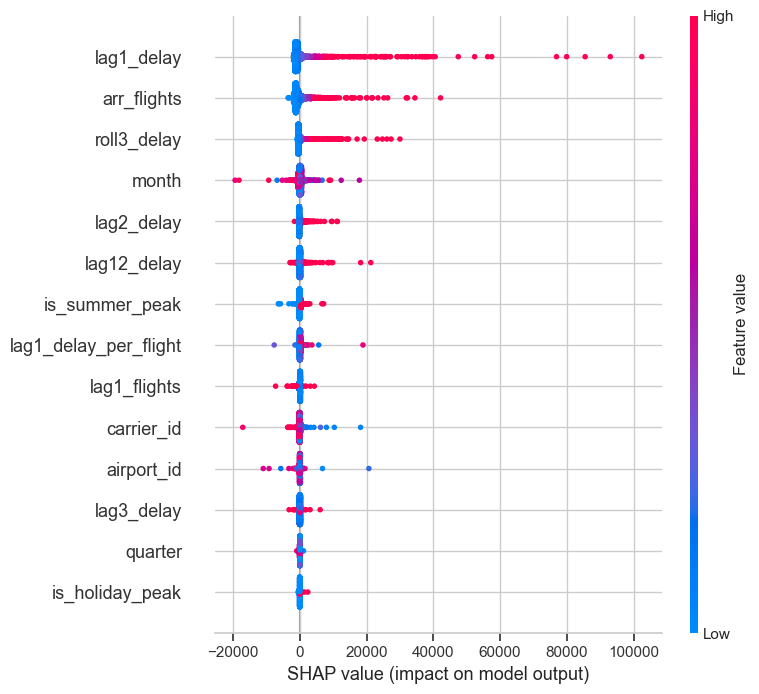

In [14]:
try:
    import shap
    sample = X_te.sample(min(2000, len(X_te)), random_state=RANDOM_STATE)
    shap_values = shap.TreeExplainer(best_xgb).shap_values(sample)
    shap.summary_plot(shap_values, sample, show=True)
except Exception as e:
    print("SHAP step skipped:", e)

## 8. Error analysis

The final blended model's test predictions, broken down by airport/route size, year, month, carrier and airport.
WAPE is total absolute error divided by total actual delay, so it stays meaningful across small and large airports.

In [15]:
err = test[["year", "month", "carrier", "airport", "arr_flights", "arr_delay"]].copy()
err["pred"] = final_pred
err["abs_err"] = (err["arr_delay"] - err["pred"]).abs()
err["volume_group"] = pd.qcut(err["arr_flights"].rank(method="first"), 4,
                              labels=["Q1 (smallest)", "Q2", "Q3", "Q4 (busiest)"])

def breakdown(by):
    g = err.groupby(by, observed=True).agg(rows=("abs_err", "size"), MAE=("abs_err", "mean"),
                                           total_err=("abs_err", "sum"), total_actual=("arr_delay", "sum"))
    g["WAPE %"] = 100 * g["total_err"] / g["total_actual"]
    return g[["rows", "MAE", "WAPE %"]].round(2)

print("By flight-volume group:");  display(breakdown("volume_group"))
print("By year:");                 display(breakdown("year"))
print("By month:");                display(breakdown("month"))

By flight-volume group:


,rows,MAE,WAPE %
volume_group,,,
Q1 (smallest),8908,254.89,71.24
Q2,8908,496.30,43.38
Q3,8908,793.29,33.19
Q4 (busiest),8908,4432.76,23.85


By year:


,rows,MAE,WAPE %
year,,,
2025,22681,1453.16,26.43
2026,12951,1566.37,26.86


By month:


,rows,MAE,WAPE %
month,,,
1,3777,1512.72,33.66
2,3741,1111.55,26.16
3,3773,1492.60,25.67
4,3722,1463.86,31.02
5,3764,1446.95,25.66
6,3769,1610.44,22.33
7,3697,1730.85,20.59
8,1920,1567.24,28.13
9,1867,1003.56,27.75


Airports contributing the most total error:


,rows,total_abs_err,MAE
airport,,,
ORD,266,3688412.1,13866.2
ATL,264,2062765.9,7813.5
DFW,222,1975931.0,8900.6
DEN,190,1687327.7,8880.7
CLT,260,1675796.4,6445.4
EWR,228,1482774.3,6503.4
LGA,208,1440635.7,6926.1
DCA,243,1366195.0,5622.2
IAH,244,1231613.6,5047.6


Carriers contributing the most total error:


,rows,total_abs_err,MAE
carrier,,,
OO,4553,7385344.6,1622.1
AA,2305,6237436.1,2706.0
WN,1992,6012511.8,3018.3
DL,2701,5620417.7,2080.9
UA,2330,5159495.3,2214.4
OH,1846,2674054.6,1448.6
YX,1546,2480343.4,1604.4
9E,1957,2213387.9,1131.0
B6,1181,2071536.7,1754.1


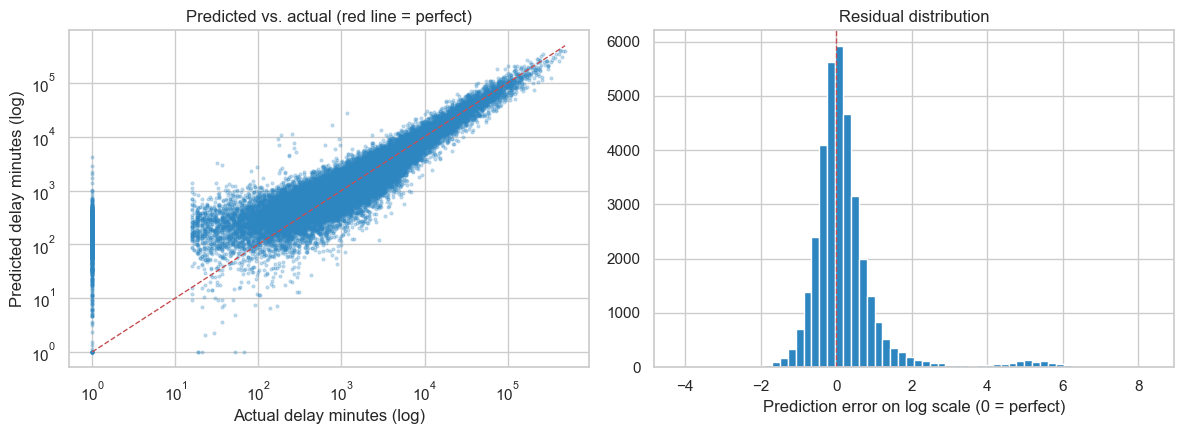

In [16]:
print("Airports contributing the most total error:")
airport_err = err.groupby("airport").agg(rows=("abs_err", "size"), total_abs_err=("abs_err", "sum"),
                                          MAE=("abs_err", "mean")).sort_values("total_abs_err", ascending=False)
display(airport_err.head(10).round(1))

print("Carriers contributing the most total error:")
carrier_err = err.groupby("carrier").agg(rows=("abs_err", "size"), total_abs_err=("abs_err", "sum"),
                                          MAE=("abs_err", "mean")).sort_values("total_abs_err", ascending=False)
display(carrier_err.head(10).round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
lim = [1, max(err["arr_delay"].max(), err["pred"].max())]
axes[0].scatter(err["arr_delay"] + 1, err["pred"] + 1, s=4, alpha=0.25, color="#2e86c1")
axes[0].plot(lim, lim, "r--", lw=1)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Actual delay minutes (log)"); axes[0].set_ylabel("Predicted delay minutes (log)")
axes[0].set_title("Predicted vs. actual (red line = perfect)")
axes[1].hist(np.log1p(err["pred"]) - np.log1p(err["arr_delay"]), bins=60, color="#2e86c1")
axes[1].axvline(0, color="r", ls="--", lw=1)
axes[1].set_xlabel("Prediction error on log scale (0 = perfect)"); axes[1].set_title("Residual distribution")
plt.tight_layout(); plt.show()

In [20]:
Practical uses
Planning ahead. Airlines and airports could forecast next month's delay minutes per carrier-airport pair and staff, schedule, and buffer for it. The model is about 24% more accurate than just assuming next month looks like this one.
Deciding where to focus. Most of the error and most of the delay sit at a few big hubs (ORD, ATL, DFW, DEN, CLT). A team with limited resources would get the most from working there first.
Knowing what to monitor. Since recent delay and flight volume predict the future best, a simple dashboard tracking those two would capture most of the signal. Holiday and calendar effects matter much less than people might assume.
Knowing what is fixable. About 70-77% of delay minutes come from carrier and late-aircraft causes, which airlines can influence, unlike weather or air traffic control.
Knowing when not to trust it. The model is least reliable for small routes, so a planner should treat predictions there with more caution.
Limits on how far to take it

These are forecasting and prioritizing tools, not proof of cause. The data is monthly totals, not individual flights, and the volume what-if shows how the model responds, not that a specific fix would work. A real operations team would need to test any change itself.

SyntaxError: unterminated string literal (detected at line 2) (726778928.py, line 2)